In [3]:
import sys, os
import numpy as np

ruta_libs = os.path.abspath("../libs")
if ruta_libs not in sys.path:
    sys.path.append(ruta_libs)

from materialLibs import *
from unitsLibs import Tank, Valve
from solveLibs import solve2TanksWithValve

In [4]:
species = ["CO2", "N2"]
WM, mu, Dm, cpg_molar, cpg_mass, k, H = get_properties_gas(species)
propiedades_gas = {
    "species": species,
    "MW": WM,
    "mu": mu,
    "Dm": Dm,
    "Cp_molar": cpg_molar,
    "Cp_mass": cpg_mass,
    "k": k,
    "H": H}

In [5]:
## TANQUE A
tankA = Tank(
    Name="TankA",
    Longitud=2.0,     # m
    Diametro=.61,     # m
    Espesor=0.02,     # m
    prop_gas=propiedades_gas,
)
tankA.initialC_info(P0=3.5e5,T0=298.0,x0=[1, 0.])
tankA.boundaryC_info(Pin=9e5,Tin=350.0,xin=[0.2, 0.8],Pout=1e5)
tankA.thermal_info(adi=True,kw=1e99,hint=1e99,hext=1e99,Tamb=298.15)

valve_A_inlet = Valve(
    Name="Entrada [Lin-Step-CO]",
    Cv_max= 1.35,  
    valve_type="linear",
    logic= "linear",
    logic_params={"start": 20, "duration": 1e-6},
    opening_direction="co")

valve_A_outlet = Valve(
    Name="Salida [Lin-Step-CO]",
    Cv_max= 1.35,  # cerrada
    valve_type="linear",
    logic= "linear",
    logic_params={"start": 20, "duration": 1e-6},
    opening_direction="co")

#TANQUE B
tankB = Tank(
    Name="TankB",
    Longitud=2.0,     # m
    Diametro=.61,     # m
    Espesor=0.02,     # m
    prop_gas=propiedades_gas,
)
tankB.initialC_info(P0=9.5e5,T0=298.0,x0=[0., 1])
tankB.boundaryC_info(Pin=9e5,Tin=350.0,xin=[0.2, 0.8],Pout=1e5)
tankB.thermal_info(adi=True,kw=1e99,hint=1e99,hext=1e99,Tamb=298.15)

valve_B_inlet = Valve(
    Name="Entrada [Lin-Step-CO]",
    Cv_max= 1.35,  
    valve_type="linear",
    logic= "linear",
    logic_params={"start": 20, "duration": 1e-6},
    opening_direction="co")

valve_B_outlet = Valve(
    Name="Salida [Lin-Step-CO]",
    Cv_max= 1.35,  # cerrada
    valve_type="linear",
    logic= "linear",
    logic_params={"start": 20, "duration": 1e-6},
    opening_direction="co")

#VALVULAS DE CONEXION 
valveAB = Valve(
    Name="ValveAB",
    Cv_max= 1.35,  
    valve_type="linear",
    logic= "linear",
    logic_params={"start": 0, "duration": 1E-6},
    opening_direction="co")

solve_ivp terminado con éxito. Tiempo simulado: 5.0 s.

⏱️ Simulation time (s): 0.078
========== BALANCE CHECK =======================
🔸 Balance de masa total (en moles):
Tanque: TankA
  N_in   = 0.000 mol
  N_out  = 0.000 mol
  N_AB   = 58.184 mol 
  N_INI  = 82.570
  N_END  = 153.361
  ΔN     = 70.791 mol
  Error  = -12.606658 mol
Tanque: TankB
  N_in   = 0.000 mol
  N_out  = 0.000 mol
  N_AB   = -58.184 mol
  N_INI  = 224.118
  N_END  = 153.327
  ΔN     = -70.791 mol
  Error  = 12.606658 mol
Balance global:
  Error neto total = 0.000000 mol


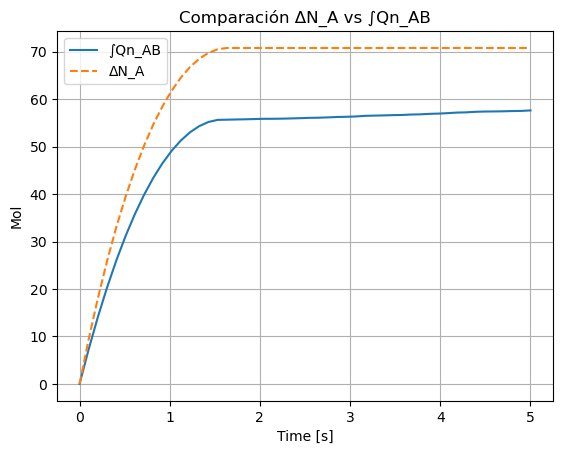

In [6]:
solve2TanksWithValve(
    Tank_A=tankA,
    Valve_A_in=valve_A_inlet,
    Valve_A_out=valve_B_outlet,
    Tank_B=tankB,
    Valve_B_in=valve_B_inlet,
    Valve_B_out=valve_B_outlet,
    Valve_AB=valveAB,
    saveData=0.1,
    endTime=5,
    solver='LSODA',
    atol=1e-3,
    rtol=1e-3,
)


In [12]:
from collections import OrderedDict
from scipy.integrate import simps

def clean_Qn_log(raw_log):
    """
    Dado un raw_log con múltiples registros (t, qn), devuelve dos arrays:
    t_clean: tiempos únicos
    qn_clean: último qn registrado para cada t
    """
    last_qn_for_t = OrderedDict()
    for t, qn in raw_log:
        last_qn_for_t[t] = qn  # sobrescribe si t ya existe
    
    t_clean = list(last_qn_for_t.keys())
    qn_clean = list(last_qn_for_t.values())
    return t_clean, qn_clean

t_clean, qn_clean = clean_Qn_log(valveAB._Qn_log)
Nm3_2_mol = 1.01325e5 / (8.314 * 273.15)
qn_mol_s = [q * Nm3_2_mol / 3600.0 for q in qn_clean]
N_total = simps(qn_clean, t_clean)  # en moles
N_total

70.70069438916809

TankA


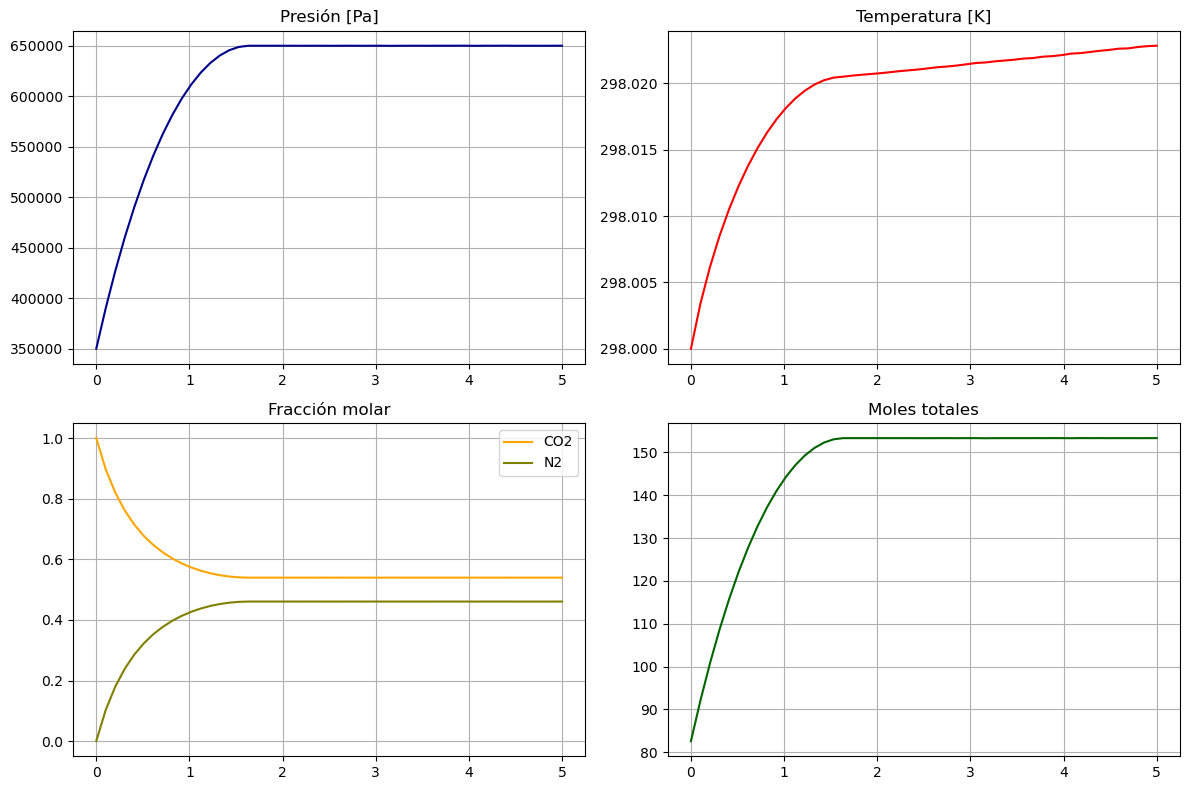

TankB


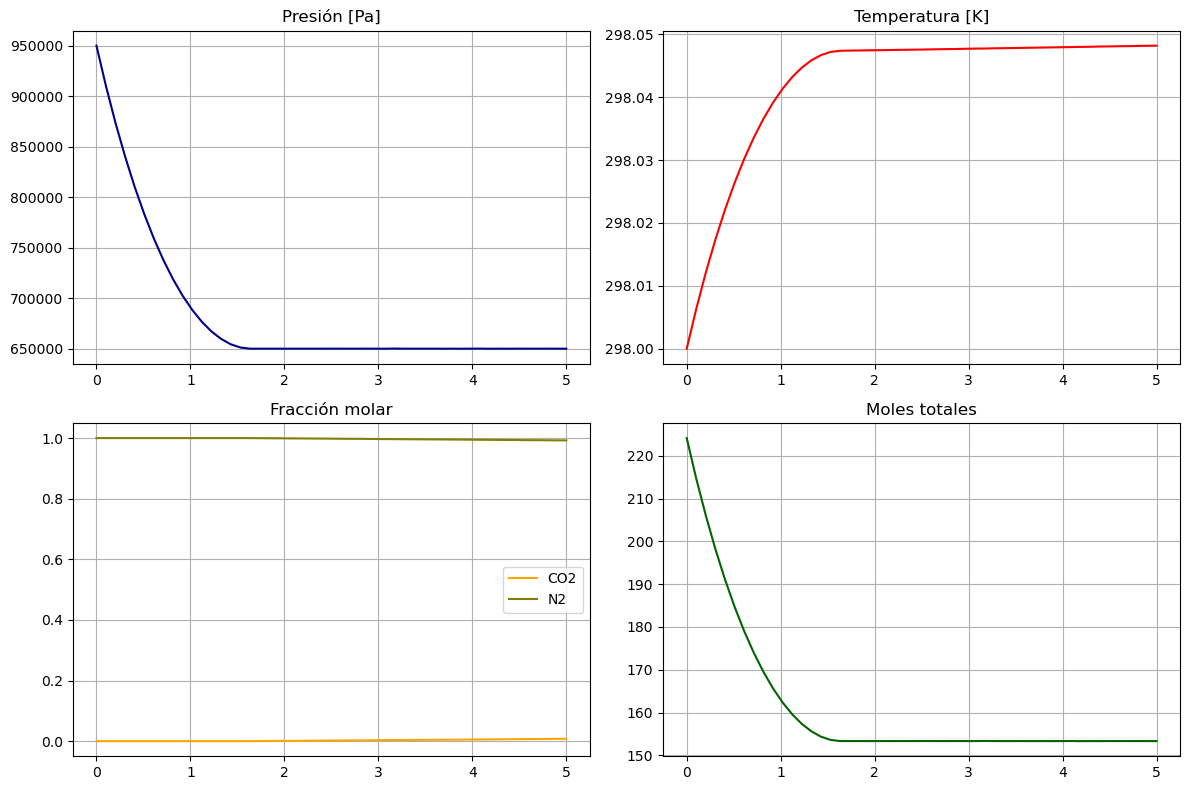

ValveAB


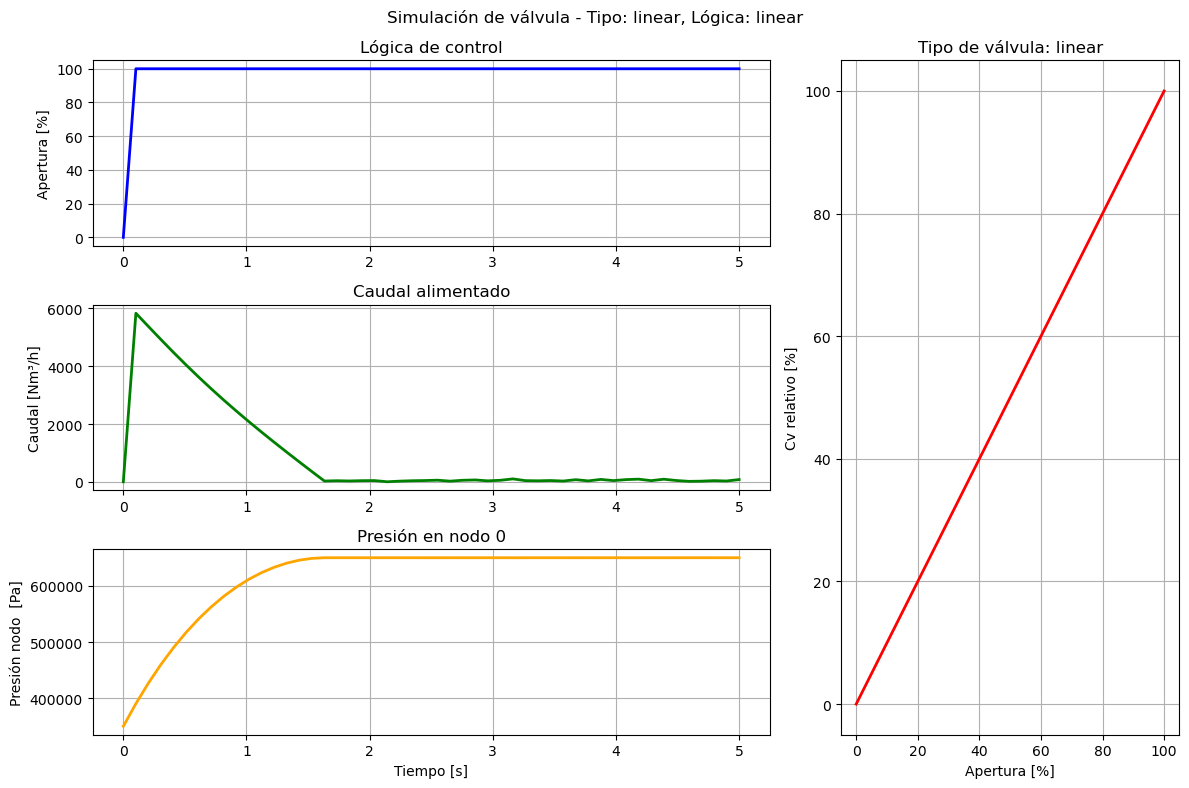

In [26]:
print(tankA._name)
tankA._plot()
print(tankB._name)
tankB._plot()
print(valveAB._name)
valveAB._plot()